# Milestone 3: Model Creation
Train, evaluate, and tune machine learning algorithms to predict song popularity based on audio features.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

RANDOM_SEED = 66
np.random.seed(RANDOM_SEED)

X_train = pd.read_csv('X_train_prepared.csv')
X_test = pd.read_csv('X_test_prepared.csv')
y_train = pd.read_csv('y_train_prepared.csv').squeeze()
y_test = pd.read_csv('y_test_prepared.csv').squeeze()

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (11248, 28)
Testing features shape: (2813, 28)


## 1. Metric Selection
Because our target (`song_popularity`) is a continuous numerical value between 0 and 100, we are solving a regression problem. We will use the following metrics to evaluate our models:
1. **RMSE (Root Mean Squared Error):** This measures the average distance between our model's predictions and the actual popularity scores. It is in the same units as our target (popularity points). Lower is better (less error).
2. **R² (R-squared):** This represents the proportion of the variance in the target variable that is predictable from our features. A score of 1.0 is perfect, 0.0 means the model is no better than guessing the average. Higher is better.

In [9]:
baseline_model = DummyRegressor(strategy='mean')
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
baseline_r2 = r2_score(y_test, baseline_preds)

print("Baseline Model Performance")
print(f"RMSE: {baseline_rmse:.2f} popularity points")
print(f"R-squared: {baseline_r2:.4f}")

results = {
    'Baseline': {'RMSE': baseline_rmse, 'R2': baseline_r2}
}

Baseline Model Performance
RMSE: 20.01 popularity points
R-squared: -0.0003


## 3. Training Machine Learning Models
We will train two different ensemble models to predict song popularity:
1. **Random Forest Regressor:** Builds multiple independent decision trees and averages them.
2. **Gradient Boosting Regressor:** Builds decision trees sequentially, with each new tree correcting the errors of the previous ones.

In [10]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Performance")
print(f"RMSE: {rf_rmse:.2f} popularity points")
print(f"R-squared: {rf_r2:.4f}")

results['Random Forest'] = {'RMSE': rf_rmse, 'R2': rf_r2}

Random Forest Performance
RMSE: 19.82 popularity points
R-squared: 0.0189


In [11]:
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_SEED)
gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
gb_r2 = r2_score(y_test, gb_preds)

print("Gradient Boosting Performance")
print(f"RMSE: {gb_rmse:.2f} popularity points")
print(f"R-squared: {gb_r2:.4f}")

results['Gradient Boosting'] = {'RMSE': gb_rmse, 'R2': gb_r2}

Gradient Boosting Performance
RMSE: 19.41 popularity points
R-squared: 0.0596


In [12]:
results_df = pd.DataFrame(results).T
print("\nCurrent Model Comparison")
print(results_df)


Current Model Comparison
                        RMSE        R2
Baseline           20.014348 -0.000252
Random Forest      19.822042  0.018878
Gradient Boosting  19.406508  0.059582


## 4. Hyperparameter Tuning
Our Gradient Boosting model performed the best, so we will select it for tuning. We will use `GridSearchCV` to test different combinations of hyperparameters:
* **`n_estimators`**: The number of sequential trees to build.
* **`learning_rate`**: How much each tree is allowed to correct the mistakes of the previous tree.
* **`max_depth`**: How deep (complex) each individual tree is allowed to grow.

*Note: We are using a modest grid and 3-fold cross-validation to keep training time reasonable.*

In [13]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4, 5]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=RANDOM_SEED),
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_gb_model = grid_search.best_estimator_

print("\nBest Hyperparameters Found")
print(grid_search.best_params_)

tuned_preds = best_gb_model.predict(X_test)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))
tuned_r2 = r2_score(y_test, tuned_preds)

print("\nTuned Gradient Boosting Performance")
print(f"RMSE: {tuned_rmse:.2f} popularity points")
print(f"R-squared: {tuned_r2:.4f}")

results['Tuned Gradient Boosting'] = {'RMSE': tuned_rmse, 'R2': tuned_r2}

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Hyperparameters Found
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

Tuned Gradient Boosting Performance
RMSE: 19.39 popularity points
R-squared: 0.0608



FINAL MODEL COMPARISON
                              RMSE        R2
Baseline                 20.014348 -0.000252
Random Forest            19.822042  0.018878
Gradient Boosting        19.406508  0.059582
Tuned Gradient Boosting  19.393553  0.060837


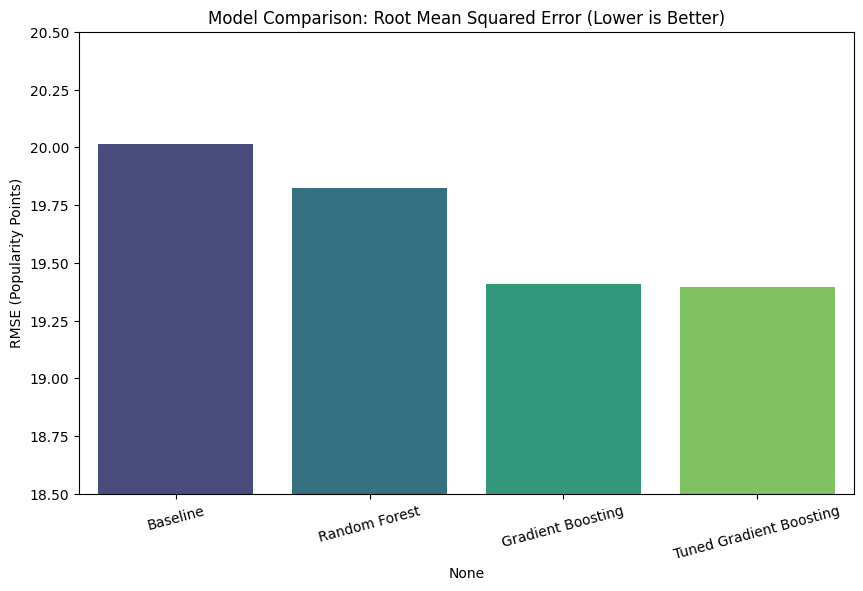

In [19]:
final_results_df = pd.DataFrame(results).T

print("\nFINAL MODEL COMPARISON")
print(final_results_df)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=final_results_df.index,
    y=final_results_df['RMSE'],
    hue=final_results_df.index,
    palette='viridis',
    legend=False
)
plt.title('Model Comparison: Root Mean Squared Error (Lower is Better)')
plt.ylabel('RMSE (Popularity Points)')
plt.xticks(rotation=15)
plt.ylim(18.5, 20.5)
plt.show()